<a href="https://colab.research.google.com/github/Kado2/EDA_videogames_sales_-_industry_data-1980_2024-/blob/main/Version_en_esp/02_Industry_Landscape.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---

<h1 style="text-align: center;font-size: 40px;">Análisis y visualización de ventas de videojuegos.</h1>

---
<center><img src="https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExejZwY3lqcGpleWh4ZnBtOTU4amQ5bTdnamZ3eGxpMDMwNmI4ZWp2ayZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/H7AsEcCf7K0fCqlB77/giphy.gif"></center>

---

Este análisis del panorama de la industria busca responder a las siguientes preguntas:

1.   ¿Qué género de juegos se ha producido más?
2.   ¿Qué año tuvo más lanzamientos de juegos?
3.   Los 5 años con más lanzamientos de juegos por género.
4.   ¿Qué género de juego ha sido lanzado más veces en un solo año?
5.   Top 20 principales editores (por volumen de títulos).
6.   Editores con más lanzamientos de cada año.


In [117]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)


import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style('whitegrid')

In [118]:
import gdown

# Enlace al .csv
url = 'https://drive.google.com/file/d/1LReqh2--v1hLgHY1SNZnKS9pxfizkopH/view?usp=drive_link'

# Nombraremos este archivo como industry_landscape_cleaned_esp.csv
output = "industry_landscape_cleaned_esp.csv"

# Realizo la descarga usando gdown
file_path = gdown.download(url, output, fuzzy=True)

df = pd.read_csv(file_path, sep=",")

Downloading...
From: https://drive.google.com/uc?id=1LReqh2--v1hLgHY1SNZnKS9pxfizkopH
To: /content/industry_landscape_cleaned_esp.csv
100%|██████████| 4.34M/4.34M [00:00<00:00, 146MB/s]


In [119]:
df.head(5)

,title,console,genre,publisher,developer,total_sales,na_sales,jp_sales,pal_sales,other_sales,year
0,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,20.32,6.37,0.99,9.85,3.12,2013
1,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,19.39,6.06,0.60,9.71,3.02,2014
2,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,16.15,8.41,0.47,5.49,1.78,2002
3,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,15.86,9.06,0.06,5.33,1.42,2013
4,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,15.09,6.18,0.41,6.05,2.44,2015


In [120]:
df.shape

(56965, 11)

# ¿Qué género de juegos se ha producido más?

In [121]:
total_by_genre = df['genre'].value_counts().reset_index()
total_by_genre.columns = ['genre', 'total_count']
total_by_genre

,genre,total_count
0,Misc,8932
1,Action,7440
2,Adventure,5370
3,Sports,5341
4,Role-Playing,4929
5,Shooter,4760
6,Platform,3556
7,Strategy,3305
8,Puzzle,3139
9,Racing,3095


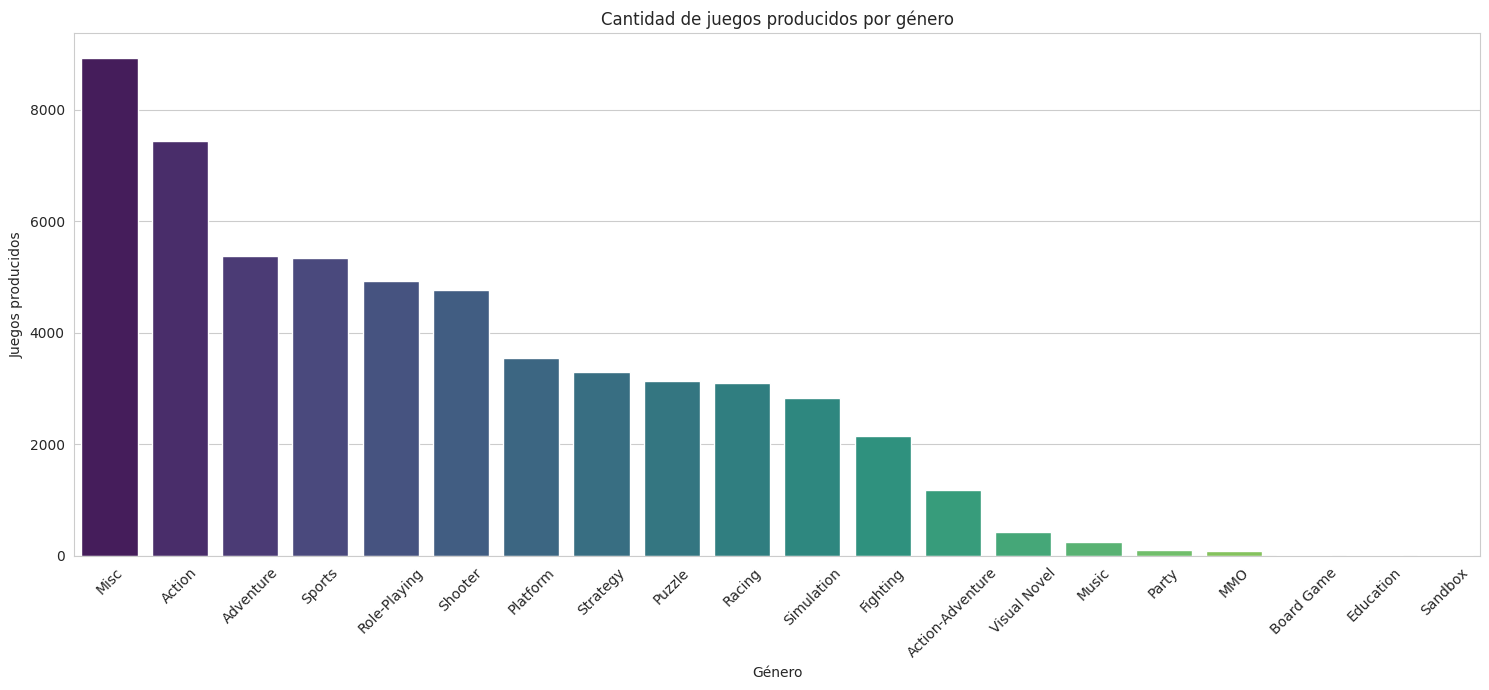

In [122]:
plt.figure(figsize=(15, 7))
sns.barplot(x='genre', y='total_count', data=total_by_genre, palette='viridis', hue='genre', legend=False)
plt.title('Cantidad de juegos producidos por género')
plt.xlabel('Género')
plt.ylabel('Juegos producidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ¿Qué año tuvo más lanzamientos de juegos?

In [123]:
lanzamientos_por_anio = df.groupby('year')['year'].value_counts().reset_index()
lanzamientos_por_anio.columns = ['Año', 'Lanzamientos']

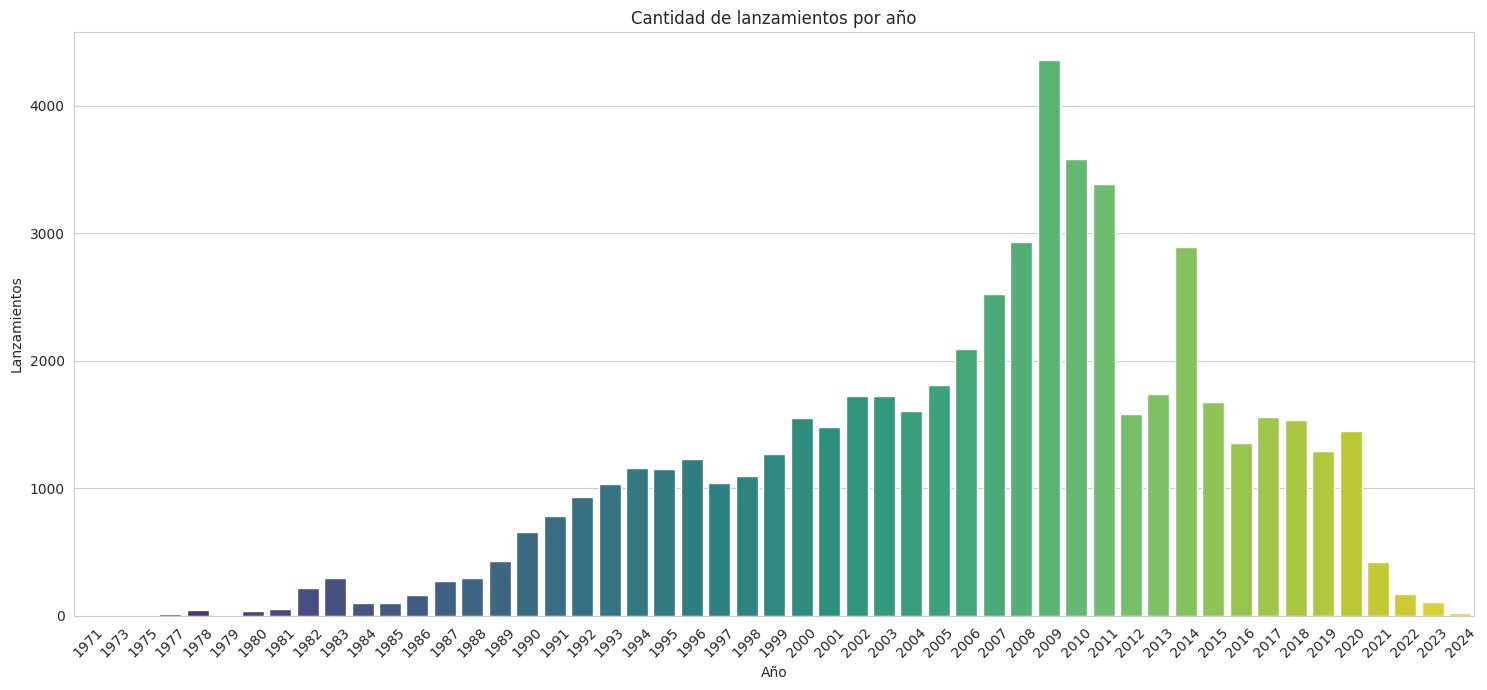

El año donde más lanzamientos hubo fue: 2009


In [124]:
plt.figure(figsize=(15, 7))
sns.barplot(x='Año', y='Lanzamientos', data=lanzamientos_por_anio, palette='viridis', hue='Año', legend=False)
plt.title('Cantidad de lanzamientos por año')
plt.xlabel('Año')
plt.ylabel('Lanzamientos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

anio_mas_lanzamientos = lanzamientos_por_anio.loc[lanzamientos_por_anio['Lanzamientos'].idxmax(), 'Año']
print("El año donde más lanzamientos hubo fue:", anio_mas_lanzamientos)

# Los 5 años con más lanzamientos de juegos por género.

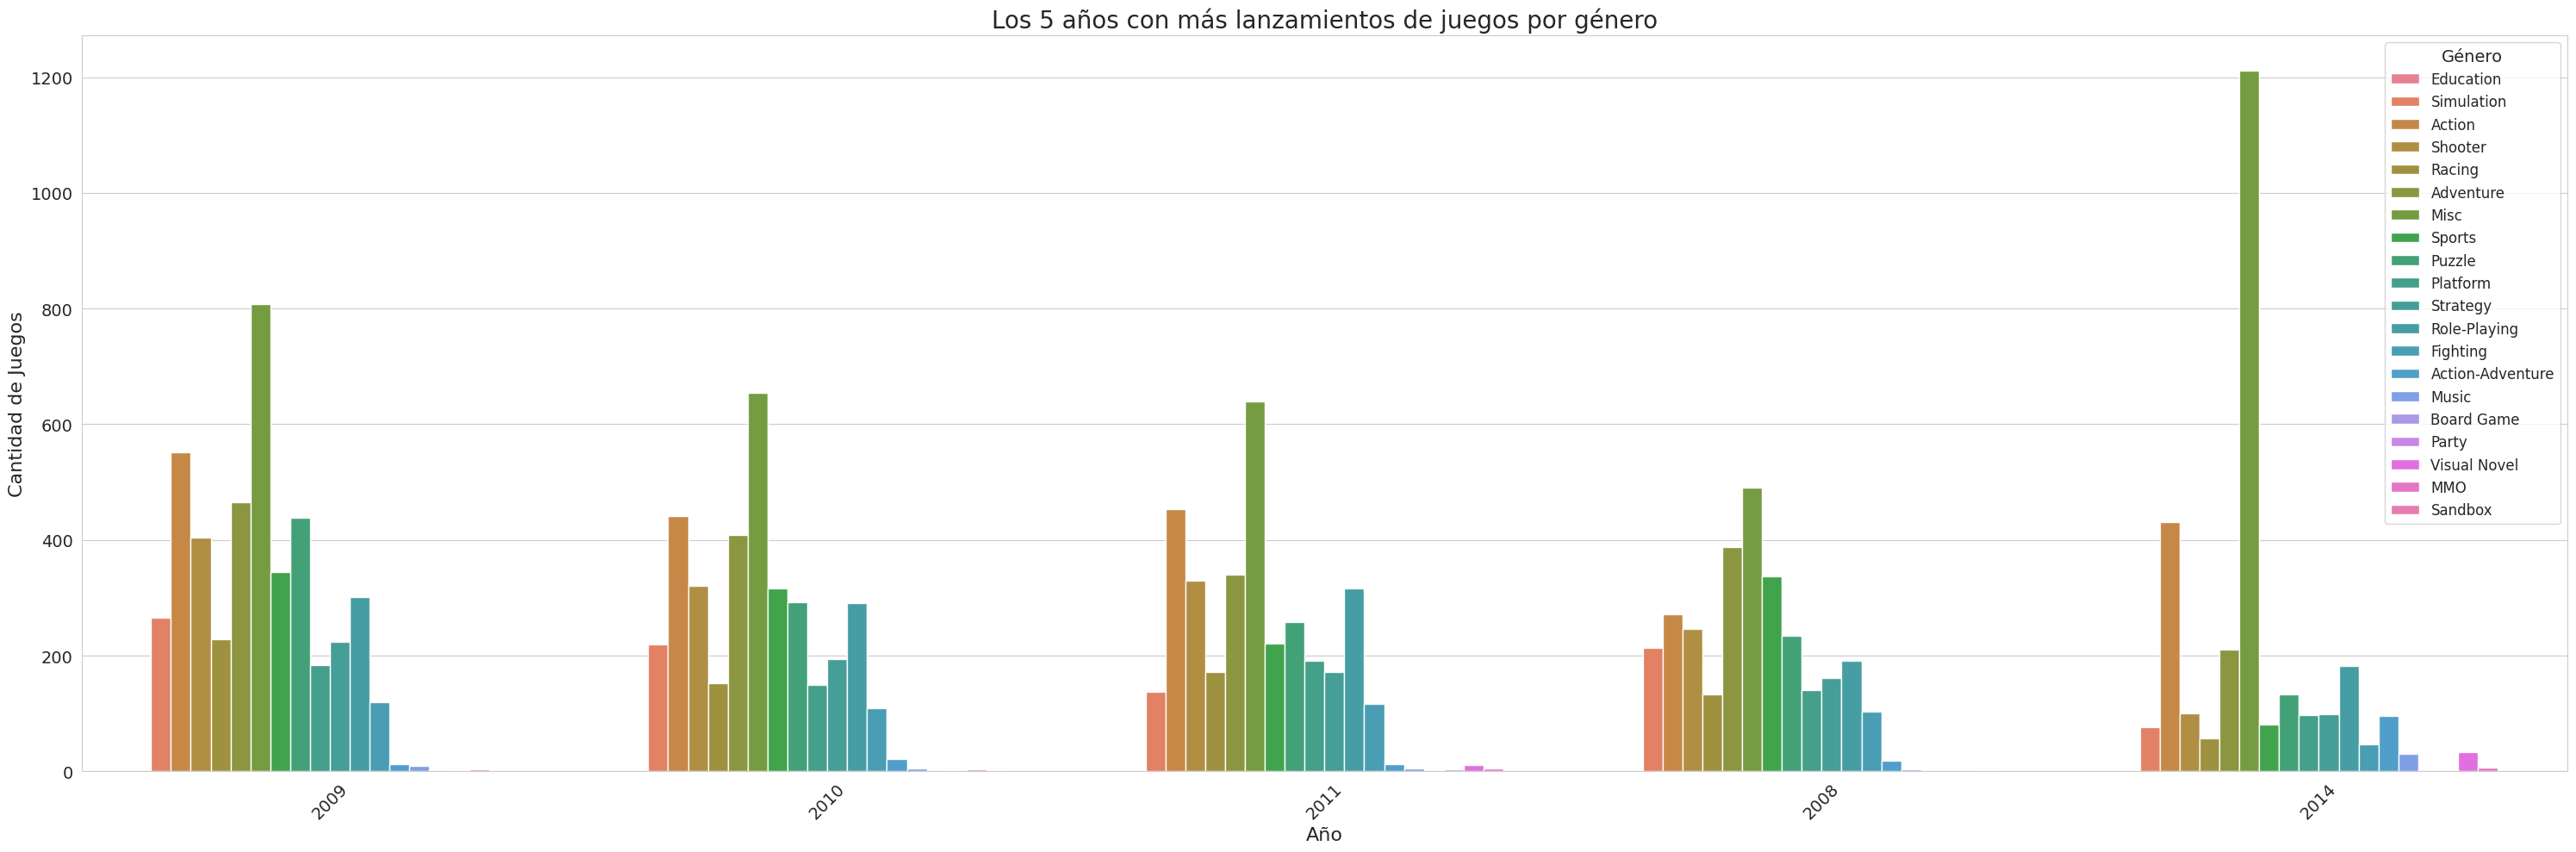

In [125]:
plt.figure(figsize=(30, 10))
sns.countplot(x="year", data=df, hue='genre', order=df.year.value_counts().iloc[:5].index)
plt.title('Los 5 años con más lanzamientos de juegos por género', fontsize=20)
plt.xlabel('Año', fontsize=16)
plt.ylabel('Cantidad de Juegos', fontsize=16)
plt.xticks(size=14, rotation=45)
plt.yticks(size=14)
plt.legend(title='Género', title_fontsize='14', fontsize='12')
plt.tight_layout()
plt.show()

# ¿Qué género de juego ha sido lanzado más veces en un solo año?

In [126]:
# Agrupa por año, género y cuenta los juegos
year_max_df = df.groupby(['year', 'genre']).size().reset_index(name='count')

# Identifica las filas donde el conteo de juegos es el máximo para cada año
year_max_idx = year_max_df.groupby(['year'])['count'].transform("max") == year_max_df['count']

# Filtra el DataFrame para quedarse solo con los géneros con el máximo de lanzamientos por año
year_max_genre = year_max_df[year_max_idx].reset_index(drop=True)

# Elimina duplicados si varios géneros tienen el mismo número máximo de lanzamientos en un año
year_max_genre = year_max_genre.drop_duplicates(subset=["year", "count"], keep='last').reset_index(drop=True)

In [127]:
# Se extrae la columna 'genre' para mayor eficiencia y legibilidad al añadir etiquetas al gráfico.
genre = year_max_genre['genre'].values

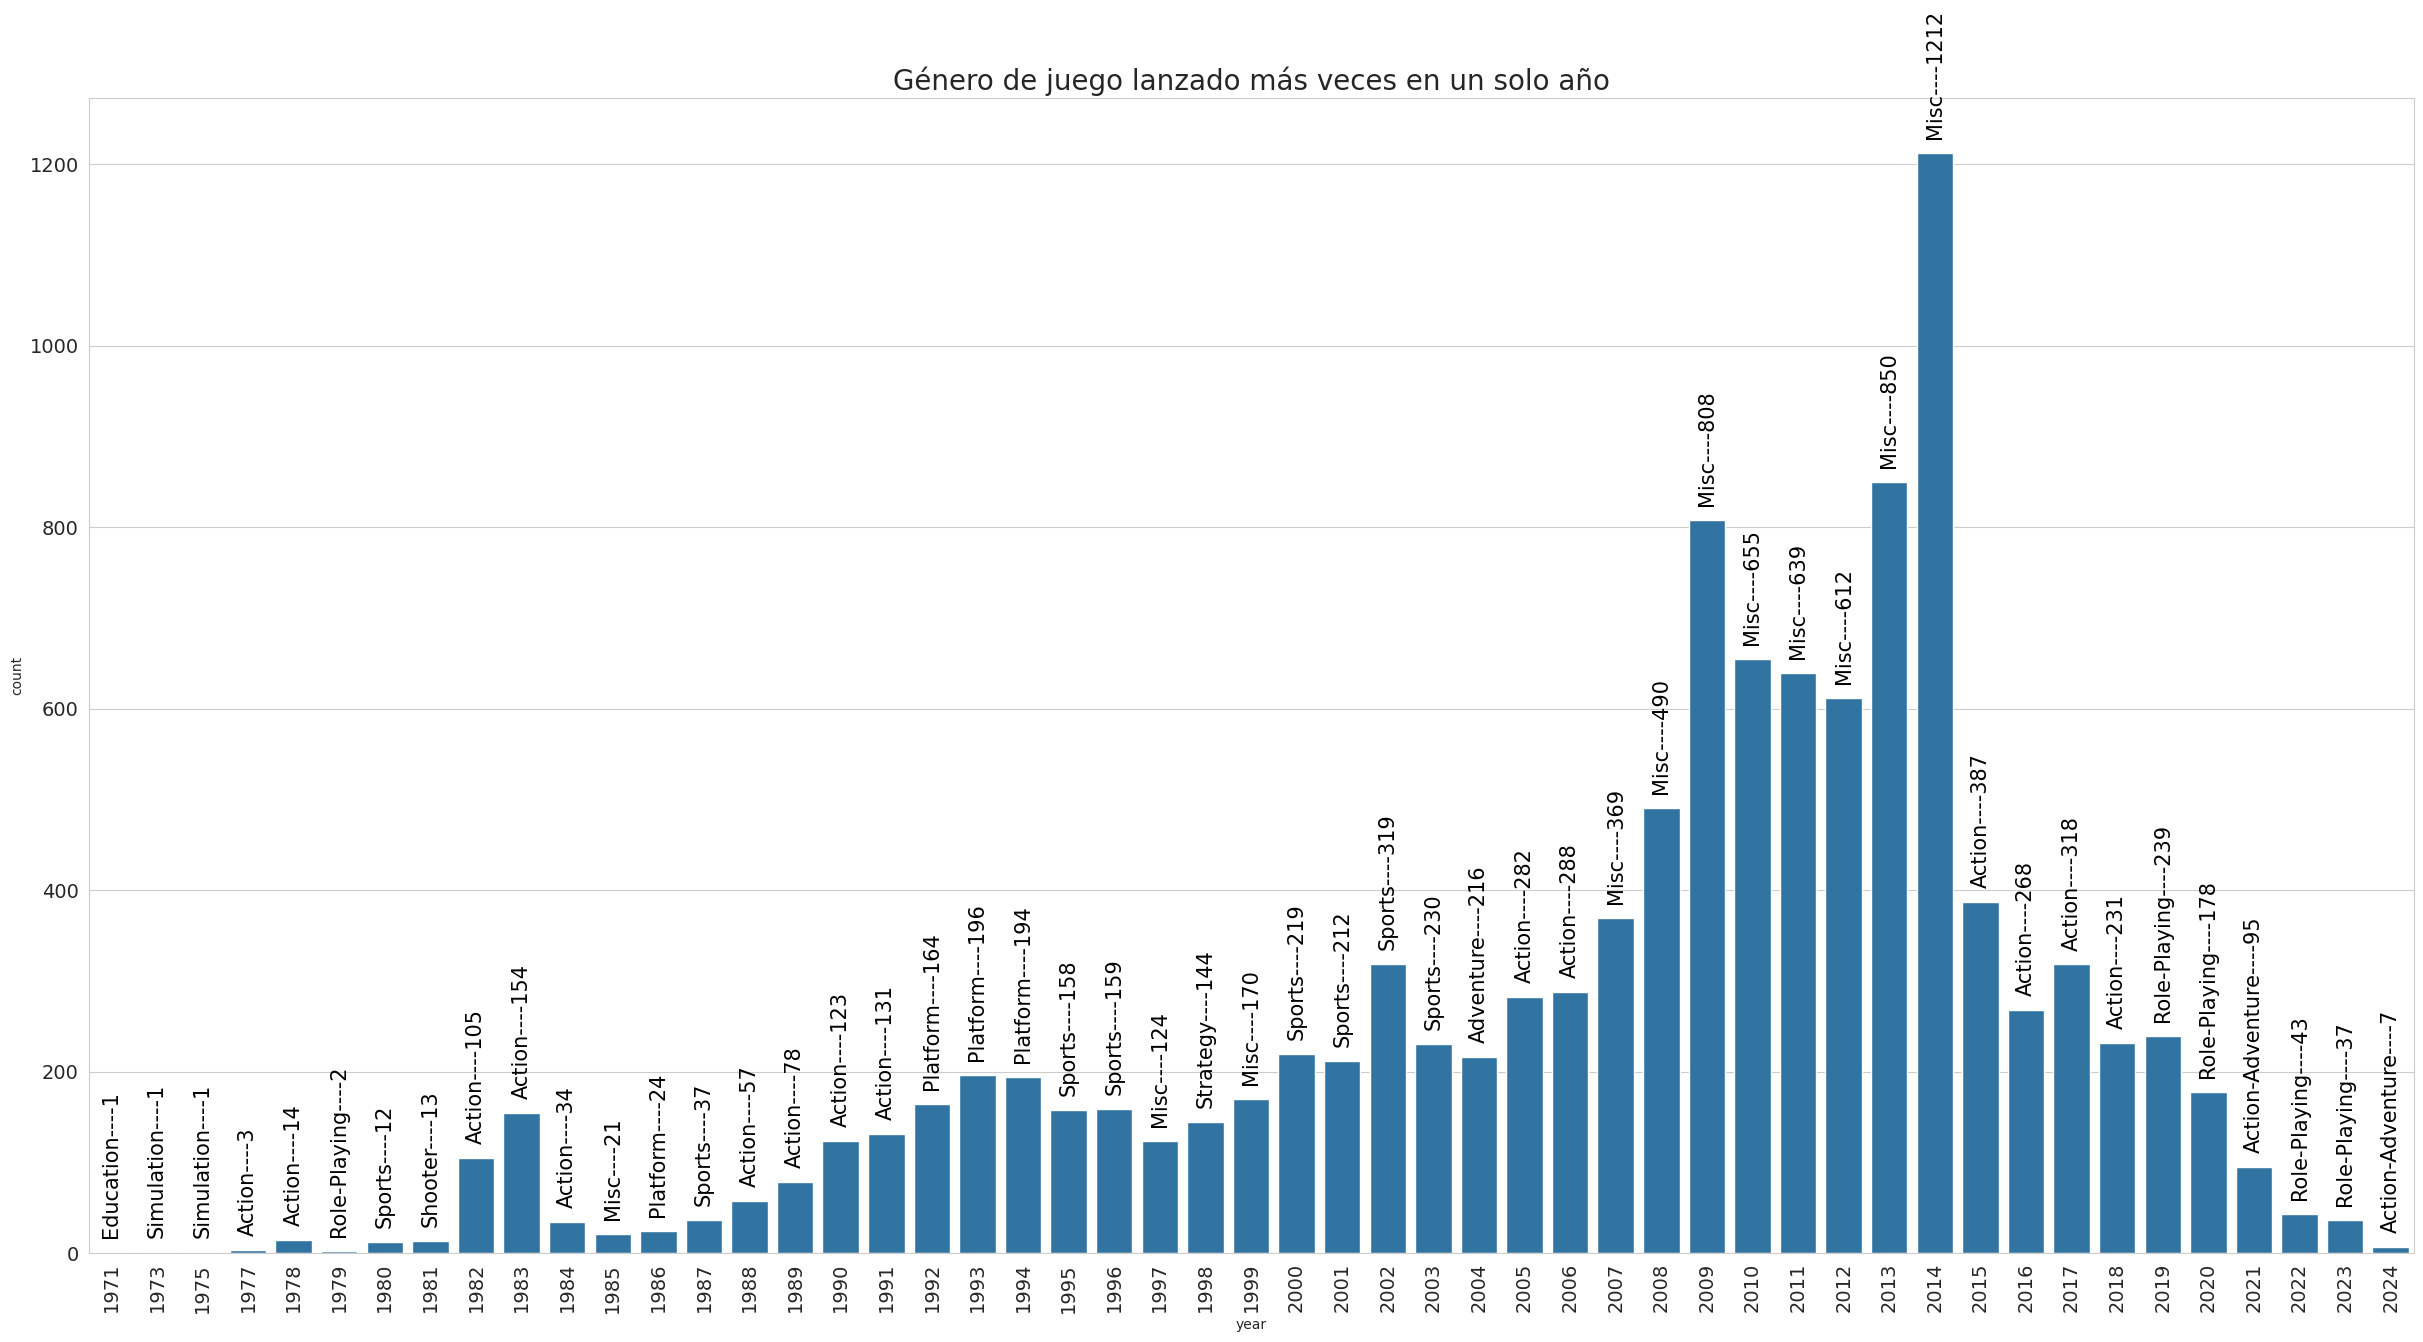

In [128]:
plt.figure(figsize=(30, 15))
g = sns.barplot(x='year', y='count', data=year_max_genre)
index = 0
for value in year_max_genre['count'].values:
    g.text(index, value + 20, str(genre[index] + '----' +str(value)), color='#000', size=15, rotation= 90, ha="center")
    index += 1
plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.title('Género de juego lanzado más veces en un solo año', fontsize=20)
plt.show()

# Top 20 principales editores (por volumen de títulos).

In [129]:
top_publishers = df['publisher'].value_counts().sort_values(ascending=False).reset_index().head(20)
top_publishers

,publisher,count
0,Sega,2207
1,Unknown,1837
2,Ubisoft,1660
3,Electronic Arts,1618
4,Activision,1581
5,Konami,1543
6,Nintendo,1475
7,Sony Computer Entertainment,1372
8,Microsoft,1271
9,THQ,1110


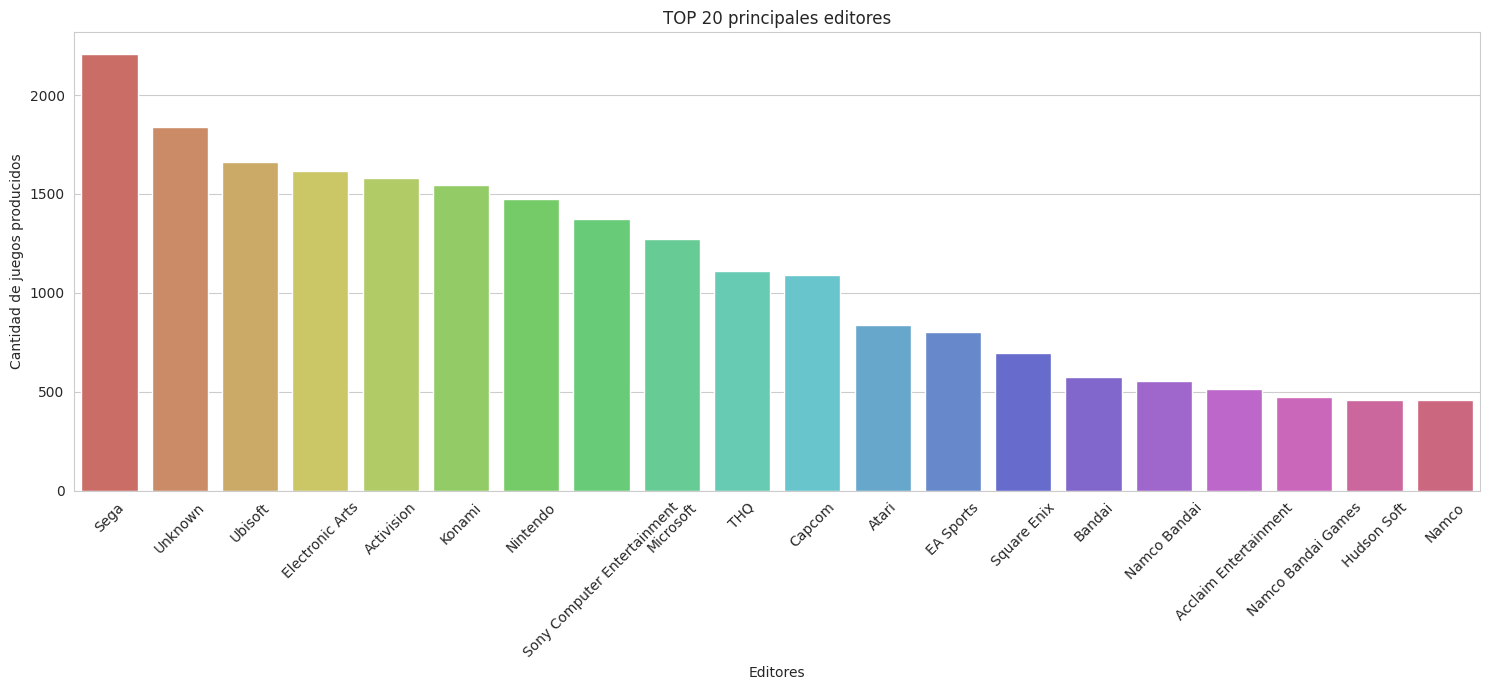

In [130]:
plt.figure(figsize=(15, 7))
sns.barplot(x='publisher', y='count', data=top_publishers, palette='hls', hue='publisher', legend=False)
plt.title('TOP 20 principales editores')
plt.xlabel('Editores')
plt.ylabel('Cantidad de juegos producidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Editores con más lanzamientos de cada año.

In [131]:
top_publisher =  df[['year', 'publisher']]

# Agrupo por año y editor para contar cuantos lanzamientos tuvieron
top_publisher_df = top_publisher.groupby(by=['year', 'publisher']).size().reset_index(name='count')

# Se busca el máximo de lanzamientos por año y creo una máscara booleana
# (da True si el editor alcanzó el récord de ese año, False si no)
top_publisher_idx =  top_publisher_df.groupby(by=['year'])['count'].transform(max) == top_publisher_df['count']

# Se aplica la máscara para filtrar
top_publisher_count = top_publisher_df[top_publisher_idx].reset_index(drop=True)

# Si dos o más editores comparten el primer puesto en un año,
# conservamos solo a uno (el último de la lista)
top_publisher_count  = top_publisher_count.drop_duplicates(subset=["year", "count"], keep='last').reset_index(drop=True)

/tmp/ipykernel_9335/1970370681.py:8: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  top_publisher_idx =  top_publisher_df.groupby(by=['year'])['count'].transform(max) == top_publisher_df['count']


In [132]:
publisher= top_publisher_count['publisher']

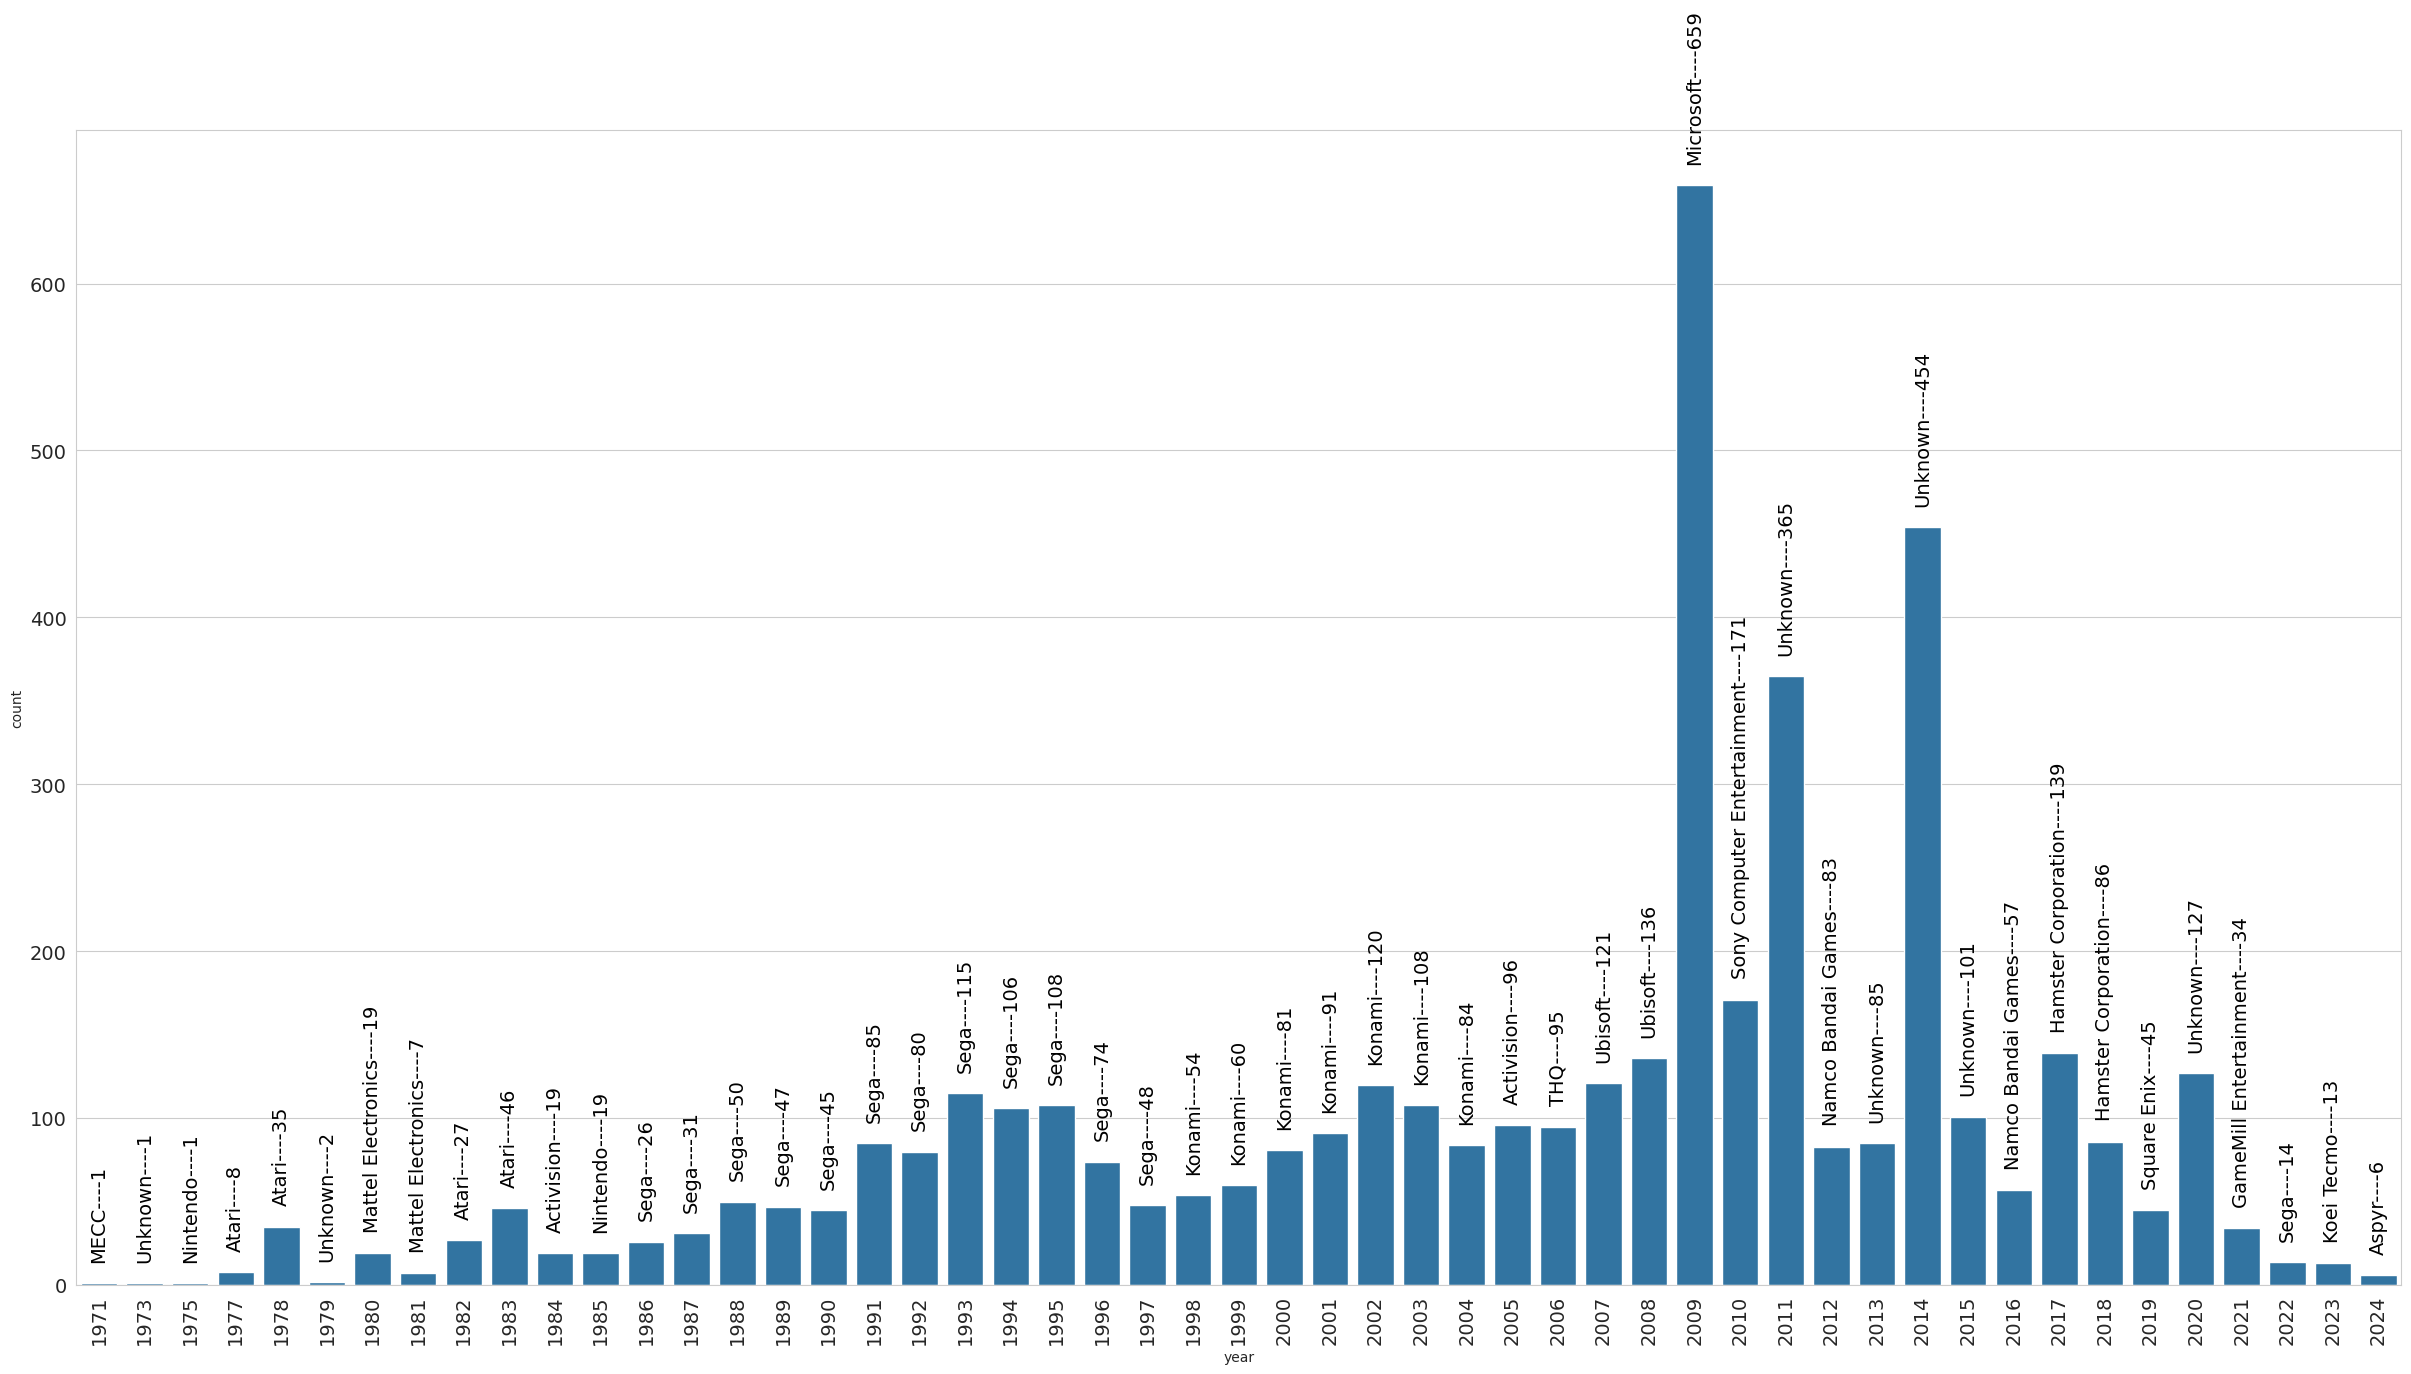

In [133]:
plt.figure(figsize=(30, 15))
g = sns.barplot(x='year', y='count', data=top_publisher_count)
index = 0
for value in top_publisher_count['count'].values:
    g.text(index, value + 15, str(publisher[index] + '----' +str(value)), color='#000', size=14, rotation= 90, ha="center")
    index += 1

plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.show()